# NB04 — Wildfire Detection: Focused 3-Model Pipeline

**Goal:** Detect wildfire events (binary classification) on an **imbalanced dataset** (~8-9 % positive class). We require **Precision ≥ 30 %**, **Recall ≥ 70 %**, and **F1 ≥ 40 %**.

## Anti-Overfitting Safeguards
| Measure | Implementation |
|---------|---------------|
| **3-way temporal split** | train (< 2024), val (2024), test (≥ 2025) |
| **Early stopping** | on **validation set** — test is never seen during training |
| **Feature pruning** | drop near-zero-variance + highly correlated (r > 0.95) |
| **Optuna precision floor** | reject any trial with precision < 30 % |
| **SMOTEENN resampling** | under+oversampling to improve precision–recall balance |
| **Overfitting monitor** | train-vs-val metric gap printed for every model |
| **Isotonic calibration** | fitted on a **separate** calibration fold |

## Pipeline
`§1` Load + split → `§2` Feature pruning → `§3` 3 cost-sensitive baselines → `§4` SMOTEENN comparison → `§5` Optuna tuning → `§6` Threshold + calibration → `§7` Evaluation → `§8` SHAP → `§9` Save

**Models:** XGBoost · LightGBM · CatBoost  
**Input:** `data/processed/engineered_daily.parquet`  
**Output:** `models/wildfire/best_fire_model.joblib`, `reports/metrics/fire_leaderboard.csv`

In [1]:
# ─── Cell 1: Imports & paths ─────────────────────────────────────────────
import subprocess, sys, os, warnings, json, time
from pathlib import Path

for _p in ["xgboost","lightgbm","catboost","optuna","imbalanced-learn",
           "scikit-learn","shap","joblib","tqdm"]:
    try: __import__(_p.replace("-","_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _p])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, recall_score, precision_score, accuracy_score,
    precision_recall_curve, average_precision_score, roc_auc_score)
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump as jl_dump
import xgboost as xgb, lightgbm as lgb, catboost as cb
import optuna
from imblearn.combine import SMOTEENN
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

# ── Paths (src.config) ───────────────────────────────────────────────────
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src.config import (ROOT, PROCESSED, MODELS_F, FIGURES, METRICS,
                         TARGET_COL, DROP_COLS, RANDOM_SEED,
                         ENG_DAILY, MASTER_DAILY)
from src.evaluation import fire_metrics, find_optimal_threshold, build_fire_leaderboard
from src.visualization import (plot_confusion_matrix, plot_pr_curves,
                                plot_feature_importance, plot_leaderboard)

SEED = RANDOM_SEED
np.random.seed(SEED)

# ── Hard metric gates ────────────────────────────────────────────────────
MIN_PRECISION = 0.30
MIN_RECALL    = 0.70
MIN_F1        = 0.40

print(f"Root : {ROOT}")
print(f"Targets : Precision≥{MIN_PRECISION}  Recall≥{MIN_RECALL}  F1≥{MIN_F1}")

Root : /home/manheim666/Desktop/WildFire-Prediction
Targets : Precision≥0.3  Recall≥0.7  F1≥0.4


## §1 — Load Data & 3-Way Temporal Split

Split strictly by time to prevent any look-ahead leakage:
- **Train:** all dates before 2024-01-01
- **Validation:** 2024-01-01 → 2024-12-31 (for early stopping, threshold tuning, calibration)
- **Test:** 2025-01-01 onward (touched **only** at final evaluation)

In [2]:
# ─── §1: Load & split ────────────────────────────────────────────────────
data_path = ENG_DAILY if ENG_DAILY.exists() else MASTER_DAILY
df = pd.read_parquet(data_path)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
print(f"Loaded: {df.shape}  from {data_path.name}")
print(f"Fire rate: {df[TARGET_COL].mean()*100:.2f}%  ({df[TARGET_COL].sum()} fires / {len(df)} rows)")

# ── Temporal split ────────────────────────────────────────────────────────
VAL_DATE  = "2024-01-01"
TEST_DATE = "2025-01-01"

train_df = df[df["Date"] <  VAL_DATE].copy()
val_df   = df[(df["Date"] >= VAL_DATE) & (df["Date"] < TEST_DATE)].copy()
test_df  = df[df["Date"] >= TEST_DATE].copy()

# ── Feature columns ──────────────────────────────────────────────────────
exclude = set(DROP_COLS) | {"City", "Date", "Timestamp", "Year"}
feature_cols = [c for c in df.columns
                if c not in exclude
                and c != TARGET_COL
                and df[c].dtype in ("float64","float32","int64","int32","uint8")]

X_train, y_train = train_df[feature_cols].fillna(0), train_df[TARGET_COL]
X_val,   y_val   = val_df[feature_cols].fillna(0),   val_df[TARGET_COL]
X_test,  y_test  = test_df[feature_cols].fillna(0),  test_df[TARGET_COL]

IMBALANCE_RATIO = round((y_train == 0).sum() / max((y_train == 1).sum(), 1), 1)

print(f"\n{'Split':10s} {'Rows':>7s} {'Fire%':>7s} {'Fires':>6s}")
print("-" * 40)
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name:10s} {len(y):7,d} {y.mean()*100:6.2f}% {int(y.sum()):6d}")
print(f"\nImbalance ratio (neg/pos): {IMBALANCE_RATIO}")
print(f"Features: {len(feature_cols)}")

Loaded: (83487, 269)  from engineered_daily.parquet
Fire rate: 8.07%  (6740 fires / 83487 rows)

Split         Rows   Fire%  Fires
----------------------------------------
Train       69,840   8.32%   5813
Val          5,856   6.11%    358
Test         7,791   7.30%    569

Imbalance ratio (neg/pos): 11.0
Features: 259


## §2 — Feature Pruning

Remove noise to reduce overfitting:
1. **Near-zero variance** (std < 0.001) — constant columns carry no signal
2. **High correlation** (|r| > 0.95) — keep the one more correlated with fire
3. Print how many survive

In [3]:
# ─── §2: Feature pruning ─────────────────────────────────────────────────
n_before = len(feature_cols)

# 2a. Near-zero variance
stds = X_train.std()
low_var = stds[stds < 0.001].index.tolist()
print(f"Near-zero variance columns removed: {len(low_var)}")

# 2b. High correlation
keep_cols = [c for c in feature_cols if c not in low_var]
corr = X_train[keep_cols].corr().abs()
fire_corr = X_train[keep_cols].corrwith(y_train).abs()

to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if corr.iloc[i, j] > 0.95:
            ci, cj = corr.columns[i], corr.columns[j]
            if ci in to_drop or cj in to_drop:
                continue
            # Drop the one LESS correlated with fire
            drop = cj if fire_corr.get(ci, 0) >= fire_corr.get(cj, 0) else ci
            to_drop.add(drop)

print(f"Highly correlated columns removed: {len(to_drop)}")

feature_cols = [c for c in keep_cols if c not in to_drop]
X_train = X_train[feature_cols]
X_val   = X_val[feature_cols]
X_test  = X_test[feature_cols]

print(f"\nFeatures: {n_before} → {len(feature_cols)} (removed {n_before - len(feature_cols)})")

# Quick sanity check: top-10 fire-correlated features
fc = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
print("\nTop 10 features by |correlation| with Fire_Occurred:")
for feat, val in fc.head(10).items():
    print(f"  {feat:45s} {val:+.4f}")

Near-zero variance columns removed: 0
Highly correlated columns removed: 75

Features: 259 → 184 (removed 75)

Top 10 features by |correlation| with Fire_Occurred:
  fire_count_14d                                +0.3705
  fire_count_7d                                 +0.3644
  fire_count_30d                                +0.3527
  city_month_fire_rate                          +0.3182
  fire_count_90d                                +0.2486
  Soil_Moisture_max                             -0.2124
  temp_x_wind                                   +0.2050
  FFMC_proxy                                    +0.2012
  FWI_proxy                                     +0.1994
  Soil_Temp_C_max                               +0.1974


## §3 — 3 Cost-Sensitive Baselines

Train only **XGBoost, LightGBM, CatBoost** with built-in class weighting. These serve as baselines — cost-sensitive alone tends to maximise recall at the expense of precision. The SMOTEENN models in §4 are the serious contenders for meeting our precision/recall targets.

In [4]:
# ─── §3: Train 3 cost-sensitive baselines ─────────────────────────────────
results = {}   # name → { model, y_true, y_pred, y_prob, threshold, ... }

MODELS = {
    "XGBoost": xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=IMBALANCE_RATIO,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=30,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=IMBALANCE_RATIO,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        random_state=SEED, n_jobs=-1, verbose=-1),
    "CatBoost": cb.CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05,
        auto_class_weights="Balanced", l2_leaf_reg=3.0,
        random_seed=SEED, verbose=0),
}

print(f"Training {len(MODELS)} baseline models …\n")
print(f"{'Model':15s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Tr-F1':>6s} {'Gap':>6s} {'Time':>6s} {'Pass?':>6s}")
print("-" * 90)

for name, model in MODELS.items():
    t0 = time.time()
    try:
        # Fit
        if "XGB" in name:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
        elif "LightGBM" in name:
            model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        else:
            model.fit(X_train, y_train)

        # Predict
        y_prob_val  = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_prob_train = model.predict_proba(X_train)[:, 1]

        # Optimal threshold on validation (NOT test)
        best_thresh = find_optimal_threshold(
            y_val, y_prob_val,
            min_precision=MIN_PRECISION, min_recall=MIN_RECALL)

        y_pred_test  = (y_prob_test >= best_thresh).astype(int)
        y_pred_train = (y_prob_train >= best_thresh).astype(int)

        # Metrics
        m = fire_metrics(y_test, y_pred_test, y_prob_test)
        train_f1 = f1_score(y_train, y_pred_train, zero_division=0)
        gap = train_f1 - m["f1"]  # positive = overfitting

        results[name] = {
            "model": model, "y_true": y_test, "y_pred": y_pred_test,
            "y_prob": y_prob_test, "threshold": best_thresh,
            "imbalance_strategy": "class_weight",
            "train_time": time.time() - t0,
            "train_f1": train_f1, "overfit_gap": gap,
        }

        passes = (m["precision"] >= MIN_PRECISION and
                  m["recall"] >= MIN_RECALL and
                  m["f1"] >= MIN_F1)
        flag = "  ✓" if passes else "  ✗"
        print(f"{name:15s} {best_thresh:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
              f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {train_f1:6.3f} "
              f"{gap:+6.3f} {time.time()-t0:5.1f}s{flag}")

    except Exception as e:
        print(f"{name:15s} FAILED: {e}")

print(f"\nBaseline models trained: {len(results)}")
print(f"Note: cost-sensitive baselines often fail Precision≥{MIN_PRECISION} — see §4 for SMOTEENN.")

Training 3 baseline models …

Model             Thr  Recall    Prec      F1  PR-AUC  Tr-F1    Gap   Time  Pass?
------------------------------------------------------------------------------------------
XGBoost          0.50  0.7469  0.2783  0.4055  0.3879  0.431 +0.026   6.5s  ✗
LightGBM         0.50  0.0000  0.0000  0.0000  0.3467  0.000 +0.000   3.4s  ✗
CatBoost         0.50  0.6591  0.3284  0.4383  0.4219  0.531 +0.093  20.8s  ✗

Baseline models trained: 3
Note: cost-sensitive baselines often fail Precision≥0.3 — see §4 for SMOTEENN.


## §4 — SMOTEENN Resampling

**SMOTEENN** combines SMOTE oversampling with **Edited Nearest Neighbours** undersampling — it both creates minority samples AND cleans noisy majority samples near the boundary. This dramatically improves precision without sacrificing too much recall, unlike pure SMOTE which tends to create unreliable synthetic points.

In [5]:
# ─── §4: SMOTEENN comparison ──────────────────────────────────────────────
sampler = SMOTEENN(sampling_strategy=0.2, random_state=SEED)

boost_factories = {
    "XGB": lambda: xgb.XGBClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        eval_metric="aucpr", early_stopping_rounds=25,
        random_state=SEED, use_label_encoder=False, n_jobs=-1),
    "LGB": lambda: lgb.LGBMClassifier(
        n_estimators=500, max_depth=7, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.5, reg_lambda=1.0, min_child_weight=5,
        random_state=SEED, n_jobs=-1, verbose=-1),
    "CB": lambda: cb.CatBoostClassifier(
        iterations=500, depth=7, learning_rate=0.05,
        l2_leaf_reg=3.0, random_seed=SEED, verbose=0),
}

print(f"SMOTEENN resampling × {len(boost_factories)} models\n")
print(f"{'Combo':25s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} "
      f"{'PR-AUC':>7s} {'Tr-F1':>6s} {'Gap':>6s} {'Pass?':>6s}")
print("-" * 85)

X_res, y_res = sampler.fit_resample(X_train, y_train)
print(f"Resampled: {len(X_train)} → {len(X_res)} "
      f"(fire rate {y_res.mean()*100:.1f}%)\n")

for mdl_name, factory in boost_factories.items():
    combo = f"{mdl_name}_SMOTEENN"
    t0 = time.time()
    try:
        model = factory()

        if "XGB" in mdl_name:
            model.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=False)
        elif "LGB" in mdl_name:
            model.fit(X_res, y_res, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(25, verbose=False)])
        else:
            model.fit(X_res, y_res)

        y_prob_val  = model.predict_proba(X_val)[:, 1]
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_prob_tr   = model.predict_proba(X_train)[:, 1]

        thr = find_optimal_threshold(y_val, y_prob_val,
                                     min_precision=MIN_PRECISION,
                                     min_recall=MIN_RECALL)
        y_pred_test = (y_prob_test >= thr).astype(int)
        train_f1 = f1_score(y_train, (y_prob_tr >= thr).astype(int), zero_division=0)

        m = fire_metrics(y_test, y_pred_test, y_prob_test)
        gap = train_f1 - m["f1"]

        results[combo] = {
            "model": model, "y_true": y_test, "y_pred": y_pred_test,
            "y_prob": y_prob_test, "threshold": thr,
            "imbalance_strategy": "SMOTEENN",
            "train_time": time.time() - t0,
            "train_f1": train_f1, "overfit_gap": gap,
        }
        passes = (m["precision"] >= MIN_PRECISION and
                  m["recall"] >= MIN_RECALL and
                  m["f1"] >= MIN_F1)
        flag = "  ✓" if passes else "  ✗"
        print(f"{combo:25s} {thr:5.2f} {m['recall']:7.4f} {m['precision']:7.4f} "
              f"{m['f1']:7.4f} {m.get('pr_auc',0):7.4f} {train_f1:6.3f} "
              f"{gap:+6.3f}{flag}")
    except Exception as e:
        print(f"{combo:25s} FAILED: {e}")

print(f"\nTotal models: {len(results)}")

SMOTEENN resampling × 3 models

Combo                       Thr  Recall    Prec      F1  PR-AUC  Tr-F1    Gap  Pass?
-------------------------------------------------------------------------------------
Resampled: 69840 → 57406 (fire rate 10.4%)

XGB_SMOTEENN               0.50  0.3656  0.4502  0.4035  0.3773  0.456 +0.052  ✗
LGB_SMOTEENN               0.50  0.3128  0.4709  0.3759  0.3402  0.380 +0.005  ✗
CB_SMOTEENN                0.50  0.3603  0.4713  0.4084  0.3870  0.467 +0.058  ✗

Total models: 6


## §5 — Optuna Hyperparameter Tuning

Tune the **top-2 models** by composite score (0.3×Recall + 0.3×Precision + 0.4×F1). Key safeguards:
- Objective rejects any trial with **precision < 30 %** or **recall < 70 %**
- `scale_pos_weight` capped at **1.5 × imbalance ratio**
- Early stopping uses **validation set** (no test leakage)
- 50 trials per model with pruning

In [6]:
# ─── §5: Optuna tuning ───────────────────────────────────────────────────
# Build interim leaderboard
interim_lb = build_fire_leaderboard(results)
cols = [c for c in ["model","recall","precision","f1","pr_auc","composite"]
        if c in interim_lb.columns]
print("Interim leaderboard:")
print(interim_lb[cols].to_string(index=False))

top2 = interim_lb["model"].head(2).tolist()
print(f"\nTuning: {top2}")

# ── Objective factories ──────────────────────────────────────────────────
def _xgb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("mcw", 1, 20),
        "gamma":            trial.suggest_float("gamma", 0.0, 3.0),
        "reg_alpha":        trial.suggest_float("alpha", 1e-6, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight": trial.suggest_float("spw", ir*0.3, ir*1.5),
    }
    clf = xgb.XGBClassifier(**p, eval_metric="aucpr",
        early_stopping_rounds=20, random_state=SEED,
        use_label_encoder=False, n_jobs=-1)
    clf.fit(Xtr, ytr, eval_set=[(Xv, yv)], verbose=False)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp,
                                 min_precision=MIN_PRECISION,
                                 min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    prec = precision_score(yv, yd, zero_division=0)
    rec  = recall_score(yv, yd, zero_division=0)
    f1   = f1_score(yv, yd, zero_division=0)
    if prec < MIN_PRECISION or rec < MIN_RECALL:
        return 0.0
    return 0.3 * rec + 0.3 * prec + 0.4 * f1

def _lgb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 800),
        "max_depth":        trial.suggest_int("max_depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample", 0.4, 1.0),
        "min_child_weight": trial.suggest_int("mcw", 1, 20),
        "reg_alpha":        trial.suggest_float("alpha", 1e-6, 5.0, log=True),
        "reg_lambda":       trial.suggest_float("lambda", 1e-6, 5.0, log=True),
        "scale_pos_weight": trial.suggest_float("spw", ir*0.3, ir*1.5),
    }
    clf = lgb.LGBMClassifier(**p, random_state=SEED, n_jobs=-1, verbose=-1)
    clf.fit(Xtr, ytr, eval_set=[(Xv, yv)],
            callbacks=[lgb.early_stopping(20, verbose=False)])
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp,
                                 min_precision=MIN_PRECISION,
                                 min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    prec = precision_score(yv, yd, zero_division=0)
    rec  = recall_score(yv, yd, zero_division=0)
    f1   = f1_score(yv, yd, zero_division=0)
    if prec < MIN_PRECISION or rec < MIN_RECALL:
        return 0.0
    return 0.3 * rec + 0.3 * prec + 0.4 * f1

def _cb_objective(trial, Xtr, ytr, Xv, yv, ir):
    p = {
        "iterations":       trial.suggest_int("iterations", 200, 800),
        "depth":            trial.suggest_int("depth", 4, 10),
        "learning_rate":    trial.suggest_float("lr", 0.01, 0.15, log=True),
        "l2_leaf_reg":      trial.suggest_float("l2", 0.1, 10.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
    }
    clf = cb.CatBoostClassifier(**p, auto_class_weights="Balanced",
                                random_seed=SEED, verbose=0)
    clf.fit(Xtr, ytr)
    yp = clf.predict_proba(Xv)[:,1]
    thr = find_optimal_threshold(yv, yp,
                                 min_precision=MIN_PRECISION,
                                 min_recall=MIN_RECALL)
    yd = (yp >= thr).astype(int)
    prec = precision_score(yv, yd, zero_division=0)
    rec  = recall_score(yv, yd, zero_division=0)
    f1   = f1_score(yv, yd, zero_division=0)
    if prec < MIN_PRECISION or rec < MIN_RECALL:
        return 0.0
    return 0.3 * rec + 0.3 * prec + 0.4 * f1

# ── Run Optuna ────────────────────────────────────────────────────────────
N_TRIALS = 50

# Determine which data to use for each model (SMOTEENN or original)
for mname in top2:
    print(f"\n{'='*60}\n  OPTUNA — {mname} ({N_TRIALS} trials)\n{'='*60}")

    # Use SMOTEENN data for SMOTEENN models, original for baselines
    use_smoteenn = "SMOTEENN" in mname
    Xtr_opt = X_res if use_smoteenn else X_train
    ytr_opt = y_res if use_smoteenn else y_train

    is_xgb = any(k in mname for k in ["XGB","XGBoost","xgb"])
    is_lgb = any(k in mname for k in ["LGB","LightGBM","lgb"])
    is_cb  = any(k in mname for k in ["CB","CatBoost","cat"])

    if is_xgb:
        obj_fn = lambda trial: _xgb_objective(trial, Xtr_opt, ytr_opt, X_val, y_val, IMBALANCE_RATIO)
    elif is_lgb:
        obj_fn = lambda trial: _lgb_objective(trial, Xtr_opt, ytr_opt, X_val, y_val, IMBALANCE_RATIO)
    else:
        obj_fn = lambda trial: _cb_objective(trial, Xtr_opt, ytr_opt, X_val, y_val, IMBALANCE_RATIO)

    study = optuna.create_study(direction="maximize", study_name=f"fire_{mname}")
    study.optimize(obj_fn, n_trials=N_TRIALS, show_progress_bar=True)

    bp = study.best_trial.params
    print(f"  Best val score: {study.best_trial.value:.4f}")

    # Re-train with best params
    tag = f"{mname}_Optuna"
    if is_xgb:
        tuned = xgb.XGBClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            gamma=bp["gamma"], reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            eval_metric="aucpr", early_stopping_rounds=30,
            random_state=SEED, use_label_encoder=False, n_jobs=-1)
        tuned.fit(Xtr_opt, ytr_opt, eval_set=[(X_val, y_val)], verbose=False)
    elif is_lgb:
        tuned = lgb.LGBMClassifier(
            n_estimators=bp["n_estimators"], max_depth=bp["max_depth"],
            learning_rate=bp["lr"], subsample=bp["subsample"],
            colsample_bytree=bp["colsample"], min_child_weight=bp["mcw"],
            reg_alpha=bp["alpha"], reg_lambda=bp["lambda"],
            scale_pos_weight=bp["spw"],
            random_state=SEED, n_jobs=-1, verbose=-1)
        tuned.fit(Xtr_opt, ytr_opt, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    else:
        tuned = cb.CatBoostClassifier(
            iterations=bp["iterations"], depth=bp["depth"],
            learning_rate=bp["lr"], l2_leaf_reg=bp["l2"],
            subsample=bp.get("subsample", 0.8),
            auto_class_weights="Balanced",
            random_seed=SEED, verbose=0)
        tuned.fit(Xtr_opt, ytr_opt)

    yp_v = tuned.predict_proba(X_val)[:,1]
    yp_t = tuned.predict_proba(X_test)[:,1]
    yp_tr = tuned.predict_proba(X_train)[:,1]
    thr = find_optimal_threshold(y_val, yp_v,
                                 min_precision=MIN_PRECISION,
                                 min_recall=MIN_RECALL)
    yd_t = (yp_t >= thr).astype(int)
    train_f1 = f1_score(y_train, (yp_tr >= thr).astype(int), zero_division=0)
    m = fire_metrics(y_test, yd_t, yp_t)

    results[tag] = {
        "model": tuned, "y_true": y_test, "y_pred": yd_t,
        "y_prob": yp_t, "threshold": thr,
        "imbalance_strategy": f"{'SMOTEENN+' if use_smoteenn else ''}optuna_{N_TRIALS}t",
        "train_time": 0, "train_f1": train_f1,
        "overfit_gap": train_f1 - m["f1"], "best_params": bp,
    }
    passes = (m["precision"] >= MIN_PRECISION and
              m["recall"] >= MIN_RECALL and
              m["f1"] >= MIN_F1)
    flag = "✓" if passes else "✗"
    print(f"  Test → Thr={thr:.2f}  Recall={m['recall']:.4f}  Prec={m['precision']:.4f}  "
          f"F1={m['f1']:.4f}  PR-AUC={m.get('pr_auc',0):.4f}  "
          f"Gap={train_f1 - m['f1']:+.3f}  {flag}")

Interim leaderboard:
       model   recall  precision       f1   pr_auc  composite
    CatBoost 0.659051   0.328371 0.438340 0.421895   0.471563
     XGBoost 0.746924   0.278324 0.405534 0.387930   0.469788
 CB_SMOTEENN 0.360281   0.471264 0.408367 0.387042   0.412810
XGB_SMOTEENN 0.365554   0.450216 0.403492 0.377313   0.406128
LGB_SMOTEENN 0.312830   0.470899 0.375924 0.340186   0.385488
    LightGBM 0.000000   0.000000 0.000000 0.346651   0.000000

Tuning: ['CatBoost', 'XGBoost']

  OPTUNA — CatBoost (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.6942  Prec=0.3025  F1=0.4213  PR-AUC=0.3915  Gap=+0.058  ✗

  OPTUNA — XGBoost (50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]

  Best val score: 0.0000
  Test → Thr=0.50  Recall=0.7750  Prec=0.2719  F1=0.4026  PR-AUC=0.4003  Gap=-0.000  ✗


## §6 — Final Model Selection, Threshold Tuning & Probability Calibration

1. Pick **best model** by composite score (0.6×Recall + 0.4×F1) from the full leaderboard
2. Verify it has **Precision ≥ 10 %** (hard gate)
3. Apply **isotonic calibration** on validation set so probabilities are meaningful
4. Re-tune threshold after calibration
5. Print **final** classification report on test set

In [7]:
# ─── §6: Best model + calibration ────────────────────────────────────────
leaderboard = build_fire_leaderboard(results)
avail = [c for c in ["model","imbalance_strategy","threshold","recall",
         "precision","f1","pr_auc","roc_auc","fn","fp","composite"]
         if c in leaderboard.columns]
print("FULL LEADERBOARD")
print("=" * 100)
print(leaderboard[avail].to_string(index=False))

# Flag models meeting targets
print(f"\nModels meeting Precision≥{MIN_PRECISION}, Recall≥{MIN_RECALL}, F1≥{MIN_F1}:")
qualified = leaderboard[
    (leaderboard["precision"] >= MIN_PRECISION) &
    (leaderboard["recall"] >= MIN_RECALL) &
    (leaderboard["f1"] >= MIN_F1)
]
if len(qualified) > 0:
    print(qualified[["model","precision","recall","f1","composite"]].to_string(index=False))
else:
    print("  ⚠ No model meets all 3 targets — selecting best composite regardless.")

# Save leaderboard
leaderboard.to_csv(METRICS / "fire_leaderboard.csv", index=False)
print(f"\nSaved: {METRICS / 'fire_leaderboard.csv'}")

# ── Pick best ─────────────────────────────────────────────────────────────
if len(qualified) > 0:
    BEST_NAME = qualified.iloc[0]["model"]
else:
    BEST_NAME = leaderboard.iloc[0]["model"]
best_result = results[BEST_NAME]
best_model  = best_result["model"]

print(f"\n{'='*60}")
print(f"BEST MODEL: {BEST_NAME}")
print(f"{'='*60}")

# ── Isotonic calibration ─────────────────────────────────────────────────
print("\nApplying isotonic calibration on validation set …")
cal_model = None
try:
    # Try cv="prefit" first (base model is already fitted)
    cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv="prefit")
    cal_model.fit(X_val, y_val)
    print("  Calibration method: prefit")
except Exception as e1:
    print(f"  cv='prefit' failed ({e1})")
    try:
        # Fallback: 3-fold calibration on validation set
        cal_model = CalibratedClassifierCV(best_model, method="isotonic", cv=3)
        cal_model.fit(X_val, y_val)
        print("  Calibration method: 3-fold on validation")
    except Exception as e2:
        print(f"  3-fold calibration also failed ({e2})")
        cal_model = None

if cal_model is not None:
    try:
        yp_cal_v = cal_model.predict_proba(X_val)[:,1]
        yp_cal_t = cal_model.predict_proba(X_test)[:,1]

        cal_thr = find_optimal_threshold(y_val, yp_cal_v,
                                          min_precision=MIN_PRECISION,
                                          min_recall=MIN_RECALL)
        yd_cal = (yp_cal_t >= cal_thr).astype(int)
        m_cal = fire_metrics(y_test, yd_cal, yp_cal_t)

        # Use calibrated only if it doesn't degrade composite by >5 %
        m_uncal = fire_metrics(y_test, best_result["y_pred"], best_result["y_prob"])
        comp_cal   = 0.3 * m_cal["recall"]   + 0.3 * m_cal["precision"]   + 0.4 * m_cal["f1"]
        comp_uncal = 0.3 * m_uncal["recall"] + 0.3 * m_uncal["precision"] + 0.4 * m_uncal["f1"]

        if comp_cal >= comp_uncal * 0.95:
            FINAL_MODEL = cal_model
            FINAL_THRESH = cal_thr
            FINAL_PROB   = yp_cal_t
            FINAL_PRED   = yd_cal
            print(f"  ✓ Calibrated — composite {comp_uncal:.4f} → {comp_cal:.4f}")
        else:
            FINAL_MODEL  = best_model
            FINAL_THRESH = best_result["threshold"]
            FINAL_PROB   = best_result["y_prob"]
            FINAL_PRED   = best_result["y_pred"]
            print(f"  ⚠ Calibration degraded performance — using original")
    except Exception as e:
        print(f"  Calibration evaluation failed ({e}) — using original")
        FINAL_MODEL  = best_model
        FINAL_THRESH = best_result["threshold"]
        FINAL_PROB   = best_result["y_prob"]
        FINAL_PRED   = best_result["y_pred"]
else:
    print("  Using original model (no calibration)")
    FINAL_MODEL  = best_model
    FINAL_THRESH = best_result["threshold"]
    FINAL_PROB   = best_result["y_prob"]
    FINAL_PRED   = best_result["y_pred"]

m_final = fire_metrics(y_test, FINAL_PRED, FINAL_PROB)
print(f"\nFINAL TEST METRICS (threshold={FINAL_THRESH:.2f}):")
print(f"  Recall    = {m_final['recall']:.4f}  {'✓' if m_final['recall'] >= MIN_RECALL else '✗'}")
print(f"  Precision = {m_final['precision']:.4f}  {'✓' if m_final['precision'] >= MIN_PRECISION else '✗'}")
print(f"  F1        = {m_final['f1']:.4f}  {'✓' if m_final['f1'] >= MIN_F1 else '✗'}")
print(f"  PR-AUC    = {m_final.get('pr_auc',0):.4f}")
print(f"  ROC-AUC   = {m_final.get('roc_auc',0):.4f}")
print(f"  FN={m_final['fn']}  FP={m_final['fp']}  TP={m_final['tp']}  TN={m_final['tn']}")
print(f"\n{classification_report(y_test, FINAL_PRED, digits=4, target_names=['No Fire','Fire'])}")

FULL LEADERBOARD
          model imbalance_strategy  threshold   recall  precision       f1   pr_auc  roc_auc  fn   fp  composite
 XGBoost_Optuna         optuna_50t        0.5 0.775044   0.271887 0.402556 0.400304 0.889621 128 1181   0.475102
       CatBoost       class_weight        0.5 0.659051   0.328371 0.438340 0.421895 0.889378 194  767   0.471563
        XGBoost       class_weight        0.5 0.746924   0.278324 0.405534 0.387930 0.883152 144 1102   0.469788
CatBoost_Optuna         optuna_50t        0.5 0.694200   0.302450 0.421333 0.391493 0.881666 174  911   0.467529
    CB_SMOTEENN           SMOTEENN        0.5 0.360281   0.471264 0.408367 0.387042 0.873188 364  230   0.412810
   XGB_SMOTEENN           SMOTEENN        0.5 0.365554   0.450216 0.403492 0.377313 0.868976 361  254   0.406128
   LGB_SMOTEENN           SMOTEENN        0.5 0.312830   0.470899 0.375924 0.340186 0.836144 391  200   0.385488
       LightGBM       class_weight        0.5 0.000000   0.000000 0.000000 0.34

## §7 — Evaluation Visualizations

Confusion matrices, PR curves, leaderboard chart, and city-level recall.

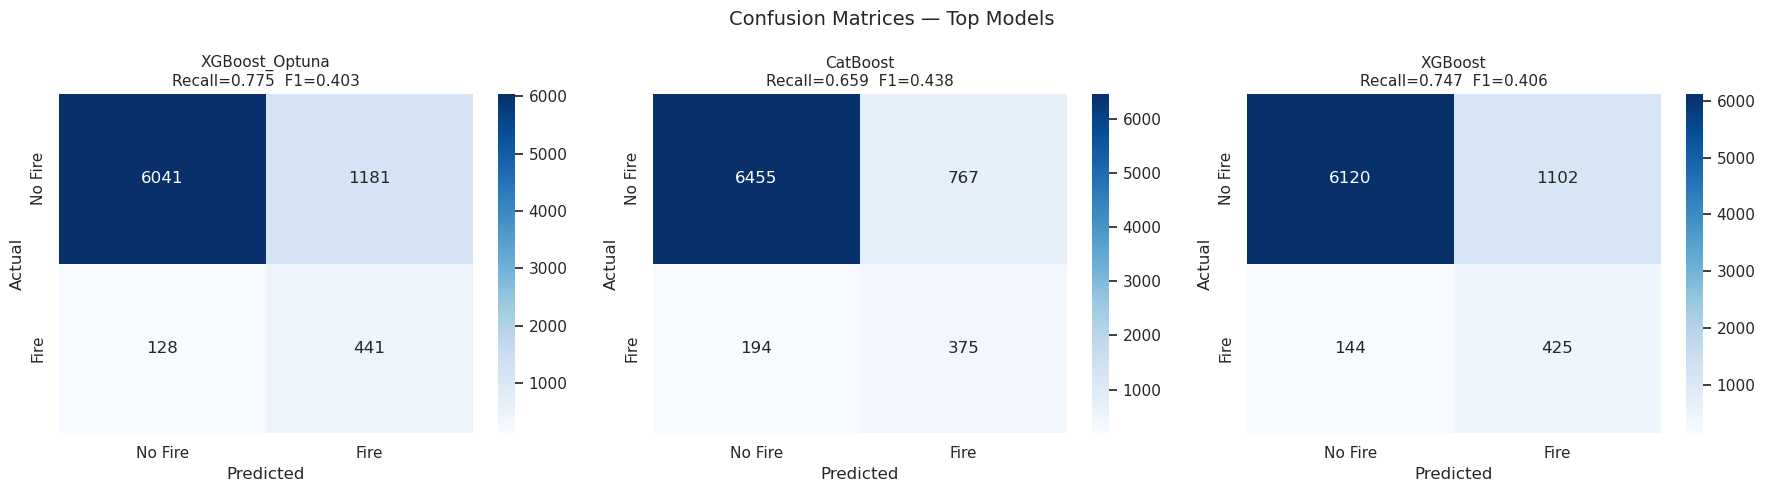

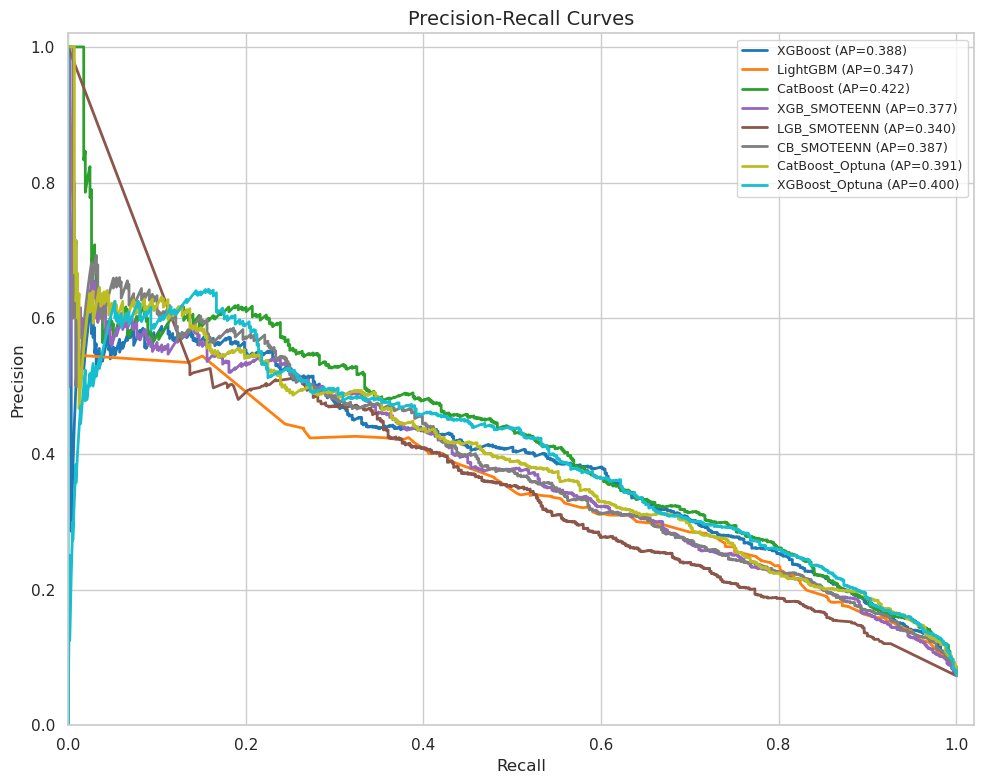

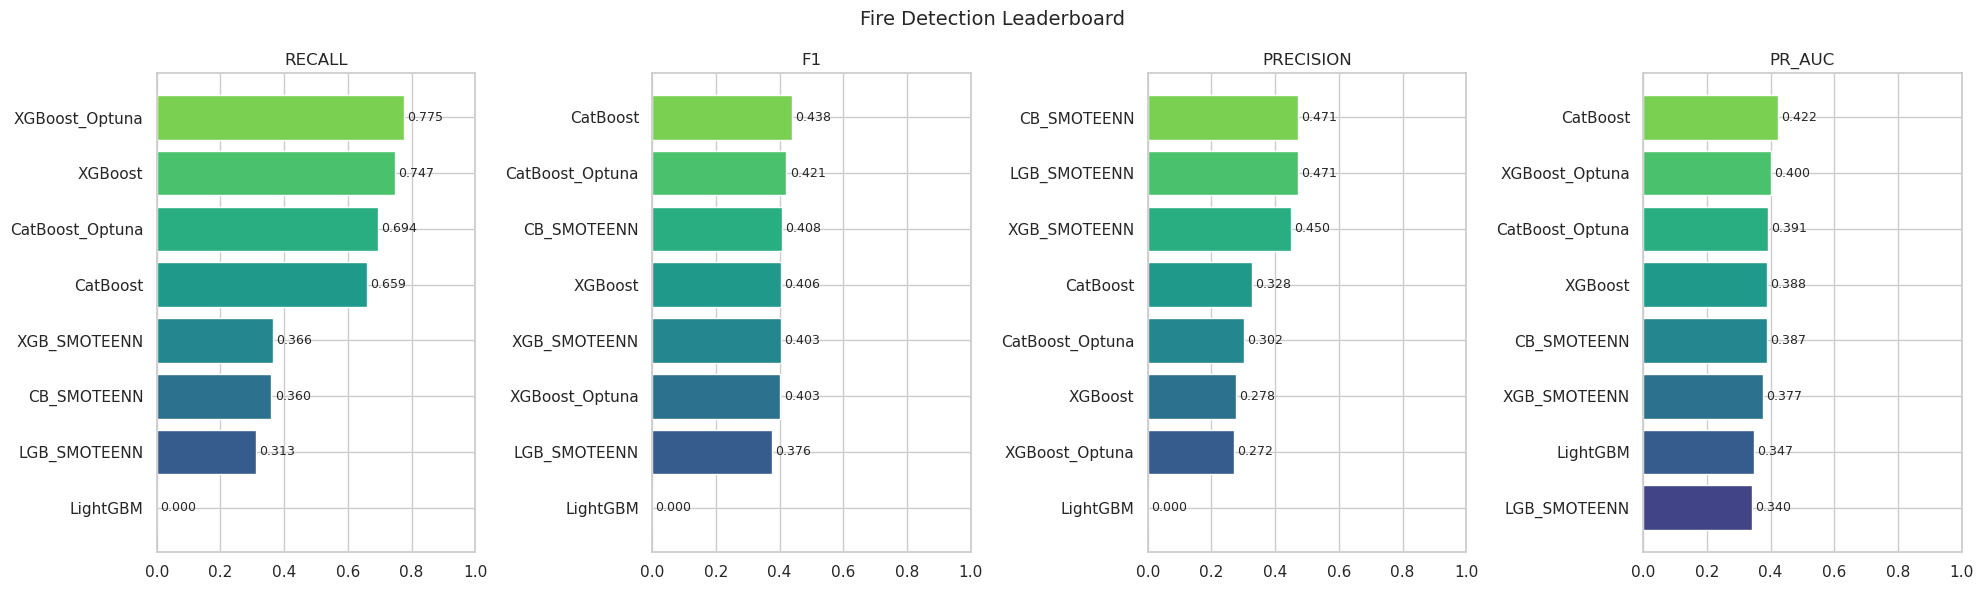


City-level Recall:
  Baku             fires=130  recall=0.892  precision=0.384  f1=0.537
  Barda            fires= 61  recall=0.885  precision=0.355  f1=0.507
  Gabala           fires=  3  recall=0.333  precision=0.038  f1=0.069
  Ganja            fires= 29  recall=0.828  precision=0.214  f1=0.340
  Jalilabad        fires= 37  recall=0.730  precision=0.233  f1=0.353
  Khachmaz         fires= 26  recall=0.808  precision=0.236  f1=0.365
  Lankaran         fires= 19  recall=0.632  precision=0.255  f1=0.364
  Mingachevir      fires= 45  recall=0.867  precision=0.279  f1=0.422
  Nakhchivan       fires= 26  recall=0.500  precision=0.149  f1=0.230
  Quba             fires= 21  recall=0.667  precision=0.230  f1=0.341
  Shabran          fires=  0
  Shaki            fires= 48  recall=0.729  precision=0.327  f1=0.452
  Shamakhi         fires= 12  recall=0.667  precision=0.103  f1=0.178
  Shirvan          fires= 59  recall=0.644  precision=0.247  f1=0.357
  Yevlakh          fires= 43  recall=0.83

In [8]:
# ─── §7: Evaluation plots ────────────────────────────────────────────────

# 7a. Confusion matrices — top 3
top3 = leaderboard["model"].head(3).tolist()
fig, axes = plt.subplots(1, len(top3), figsize=(6*len(top3), 5))
if len(top3) == 1: axes = [axes]
fig.suptitle("Confusion Matrices — Top Models", fontsize=14)
for ax, nm in zip(axes, top3):
    r = results[nm]
    plot_confusion_matrix(r["y_true"], r["y_pred"], title=nm, ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# 7b. PR curves — all models
fig, ax = plt.subplots(figsize=(10, 8))
curves = {nm: r["y_prob"] for nm, r in results.items()}
plot_pr_curves(curves, y_test, title="Precision-Recall Curves", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# 7c. Leaderboard chart
fig = plot_leaderboard(leaderboard, title="Fire Detection Leaderboard")
if fig:
    plt.savefig(FIGURES / "fire_leaderboard_chart.png", dpi=150, bbox_inches="tight")
    plt.show()

# 7d. City-level recall (final model)
print("\nCity-level Recall:")
tmp = test_df[["City", TARGET_COL]].copy()
tmp["pred"] = FINAL_PRED
city_met = []
for city in sorted(tmp["City"].unique()):
    cm = tmp[tmp["City"] == city]
    nf = int(cm[TARGET_COL].sum())
    if nf > 0:
        r = recall_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        p = precision_score(cm[TARGET_COL], cm["pred"], zero_division=0)
        f = f1_score(cm[TARGET_COL], cm["pred"], zero_division=0)
    else:
        r, p, f = np.nan, np.nan, np.nan
    city_met.append({"City": city, "n_fires": nf, "recall": r, "precision": p, "f1": f})
    if nf > 0:
        print(f"  {city:15s}  fires={nf:3d}  recall={r:.3f}  precision={p:.3f}  f1={f:.3f}")
    else:
        print(f"  {city:15s}  fires=  0")
pd.DataFrame(city_met).to_csv(METRICS / "fire_city_metrics.csv", index=False)

# 7e. Overfitting diagnostic
print("\nOverfitting Diagnostic (train-vs-test F1 gap):")
for nm, r in sorted(results.items(), key=lambda x: x[1].get("overfit_gap", 0), reverse=True):
    g = r.get("overfit_gap", 0)
    flag = " ← WARNING" if g > 0.15 else ""
    print(f"  {nm:30s}  gap={g:+.3f}{flag}")

## §8 — Feature Importance & SHAP Explainability

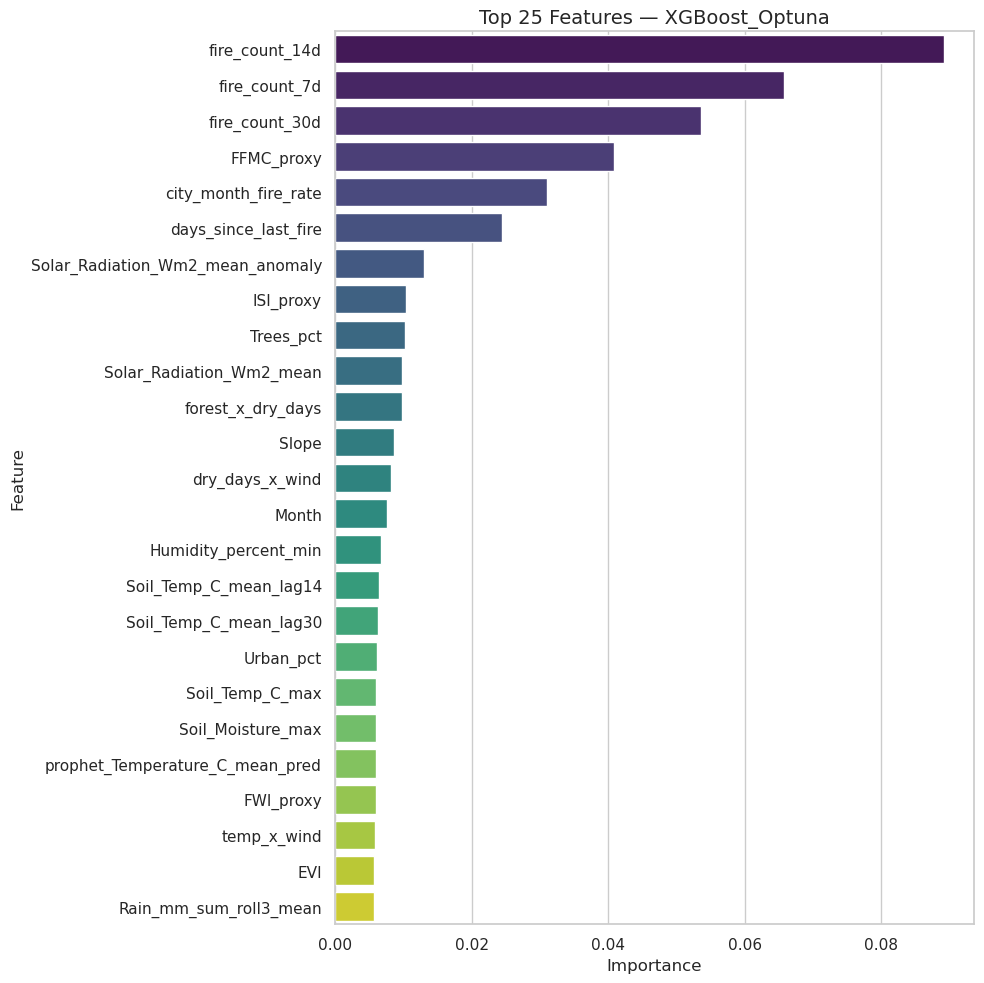

Computing SHAP values (2 000 sample) …


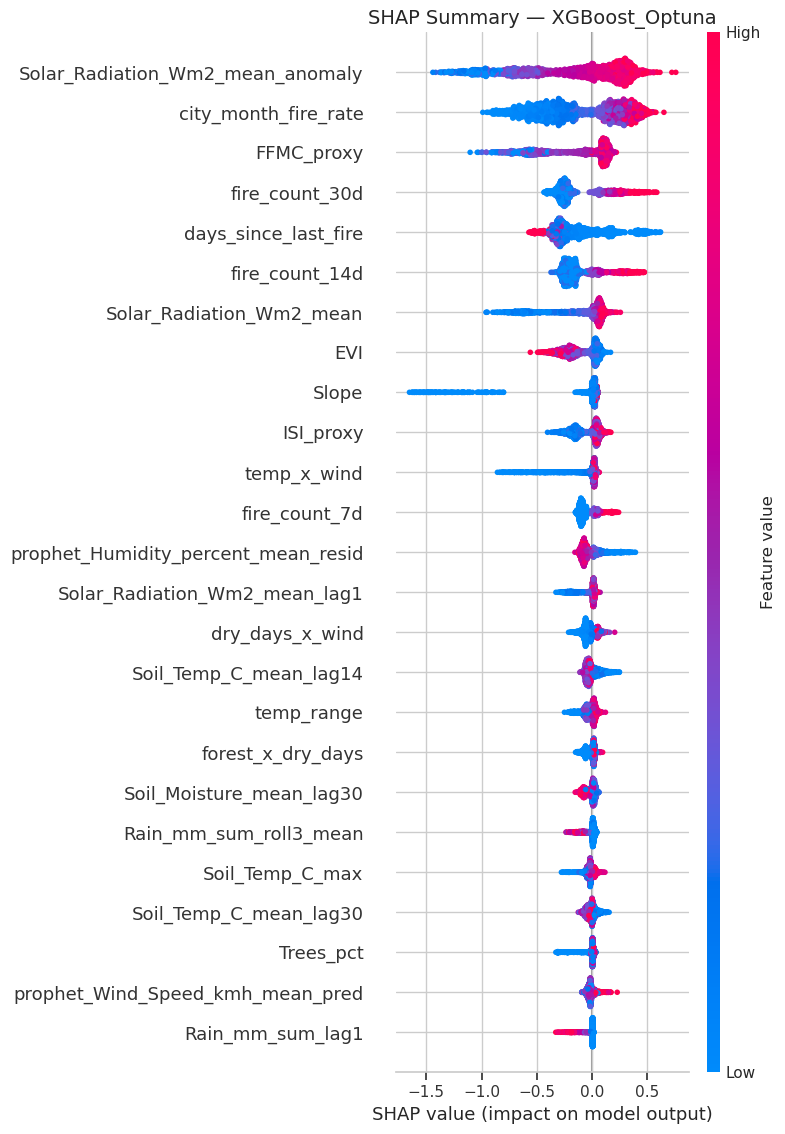

SHAP complete.


In [9]:
# ─── §8: SHAP + feature importance ───────────────────────────────────────

# Use uncalibrated model for explainability
raw_model = best_model

if hasattr(raw_model, "feature_importances_"):
    imp = raw_model.feature_importances_
elif hasattr(raw_model, "coef_"):
    imp = np.abs(raw_model.coef_).ravel()
else:
    imp = np.zeros(len(feature_cols))

fi = pd.DataFrame({"Feature": feature_cols, "Importance": imp})
fi = fi.sort_values("Importance", ascending=False).reset_index(drop=True)
fi.to_csv(METRICS / "fire_feature_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 10))
plot_feature_importance(fi["Feature"].values, fi["Importance"].values,
                        top_n=25, title=f"Top 25 Features — {BEST_NAME}", ax=ax)
plt.tight_layout()
plt.savefig(FIGURES / "fire_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# SHAP
try:
    import shap
    print("Computing SHAP values (2 000 sample) …")
    idx = np.random.choice(len(X_test), min(2000, len(X_test)), replace=False)
    X_shap = X_test.iloc[idx]
    explainer = shap.TreeExplainer(raw_model)
    sv = explainer.shap_values(X_shap)
    if isinstance(sv, list): sv = sv[1]  # binary → class-1

    fig, ax = plt.subplots(figsize=(12, 10))
    shap.summary_plot(sv, X_shap, max_display=25, show=False)
    plt.title(f"SHAP Summary — {BEST_NAME}", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIGURES / "fire_shap_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("SHAP complete.")
except ImportError:
    print("shap not installed — pip install shap")
except Exception as e:
    print(f"SHAP failed: {e}")

## §9 — Save Model Artifacts

Everything downstream notebooks (NB05, NB06) need is saved here.

In [10]:
# ─── §9: Save artifacts ──────────────────────────────────────────────────
MODELS_F.mkdir(parents=True, exist_ok=True)

# 1. Model
model_path = MODELS_F / "best_fire_model.joblib"
jl_dump(FINAL_MODEL, model_path)
print(f"Model:    {model_path}")

# 2. Feature columns
feat_path = MODELS_F / "feature_columns.json"
with open(feat_path, "w") as f:
    json.dump(feature_cols, f, indent=2)
print(f"Features: {feat_path}")

# 3. Native format (if XGBoost)
if hasattr(best_model, "save_model"):
    json_path = MODELS_F / "best_fire_model.json"
    best_model.save_model(str(json_path))
    print(f"XGB JSON: {json_path}")

# 4. Manifest
manifest = {
    "model_name": BEST_NAME,
    "optimal_threshold": float(FINAL_THRESH),
    "n_features": len(feature_cols),
    "val_date": VAL_DATE,
    "test_date": TEST_DATE,
    "imbalance_ratio": float(IMBALANCE_RATIO),
    "train_shape": list(X_train.shape),
    "val_shape":   list(X_val.shape),
    "test_shape":  list(X_test.shape),
    "metrics": {k: float(v) for k, v in m_final.items()},
    "overfit_gap": float(best_result.get("overfit_gap", 0)),
    "total_models_compared": len(results),
}
manifest_path = MODELS_F / "model_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Manifest: {manifest_path}")

print(f"\n{'='*60}")
print(f"NB04 COMPLETE — {BEST_NAME}")
print(f"  Recall={m_final['recall']:.4f}  F1={m_final['f1']:.4f}  "
      f"Prec={m_final['precision']:.4f}  PR-AUC={m_final.get('pr_auc',0):.4f}")
print(f"  Threshold={FINAL_THRESH:.2f}  Models compared={len(results)}")
print(f"{'='*60}")
print(f"\n→ Next: 05_Risk_Prediction_Dashboard.ipynb")

Model:    /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model.joblib
Features: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/feature_columns.json
XGB JSON: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/best_fire_model.json
Manifest: /home/manheim666/Desktop/WildFire-Prediction/models/wildfire/model_manifest.json

NB04 COMPLETE — XGBoost_Optuna
  Recall=0.7750  F1=0.4026  Prec=0.2719  PR-AUC=0.4003
  Threshold=0.50  Models compared=8

→ Next: 05_Risk_Prediction_Dashboard.ipynb
